In [ ]:
#Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Telling seasborn to make our plots look clean with a white grid
sns.set_theme(style="whitegrid")

# Loading my CSV file into a dataframe named df
df=pd.read_csv('churn-bigml-80.csv')

TASK 1: DATA CLEANING AND PRE-PROCESSING

In [ ]:
# INSPECT THE STRUCTURE
print("Dimensions of dataset:", df.shape)
df.head

Dimensions of dataset: (2666, 20)


<bound method NDFrame.head of      State  Account length  Area code International plan Voice mail plan  \
0       KS             128        415                 No             Yes   
1       OH             107        415                 No             Yes   
2       NJ             137        415                 No              No   
3       OH              84        408                Yes              No   
4       OK              75        415                Yes              No   
...    ...             ...        ...                ...             ...   
2661    SC              79        415                 No              No   
2662    AZ             192        415                 No             Yes   
2663    WV              68        415                 No              No   
2664    RI              28        510                 No              No   
2665    TN              74        415                 No             Yes   

      Number vmail messages  Total day minutes  Total day

In [ ]:
#Checking data types 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [ ]:
#Check if any cell is empty
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [ ]:
#Check and remove duplicate rows
print("Duplicate rows found:", df.duplicated().sum())
# If there was duplicates,I'll drop them while keeping the original:
df = df.drop_duplicates()

Duplicate rows found: 0


In [ ]:

# Converting the strings to binary
df['International plan'] = df['International plan'].map({'Yes':1, 'No':0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes':1, 'No':0})
df['Churn'] = df['Churn'].astype(int)

#Verifying the changes
df[['International plan', 'Voice mail plan', 'Churn']].head()

,International plan,Voice mail plan,Churn
0,0,1,0
1,0,1,0
2,0,0,0
3,1,0,0
4,1,0,0


                                                    TASK 2: EXPLORATORY DATA ANALYSIS(EDA)

In [ ]:
#Generating thesummary(Mean, Std, Min, 25%, 50%, 75%, Max)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Account length,2666.0,100.620405,39.563974,1.00,73.0000,100.00,127.000,243.00
Area code,2666.0,437.438860,42.521018,408.00,408.0000,415.00,510.000,510.00
International plan,2666.0,0.101275,0.301750,0.00,0.0000,0.00,0.000,1.00
Voice mail plan,2666.0,0.274944,0.446570,0.00,0.0000,0.00,1.000,1.00
Number vmail messages,2666.0,8.021755,13.612277,0.00,0.0000,0.00,19.000,50.00
Total day minutes,2666.0,179.481620,54.210350,0.00,143.4000,179.95,215.900,350.80
Total day calls,2666.0,100.310203,19.988162,0.00,87.0000,101.00,114.000,160.00
Total day charge,2666.0,30.512404,9.215733,0.00,24.3800,30.59,36.700,59.64
Total eve minutes,2666.0,200.386159,50.951515,0.00,165.3000,200.90,235.100,363.70
Total eve calls,2666.0,100.023631,20.161445,0.00,87.0000,100.00,114.000,170.00


Customer Churn Counts:
Churn
0    2278
1     388
Name: count, dtype: int64

Customer Churn Percntages:
Churn
0    85.45
1    14.55
Name: proportion, dtype: float64


C:\Users\abdul\AppData\Local\Temp\ipykernel_23516\1767228805.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette = 'Set2')


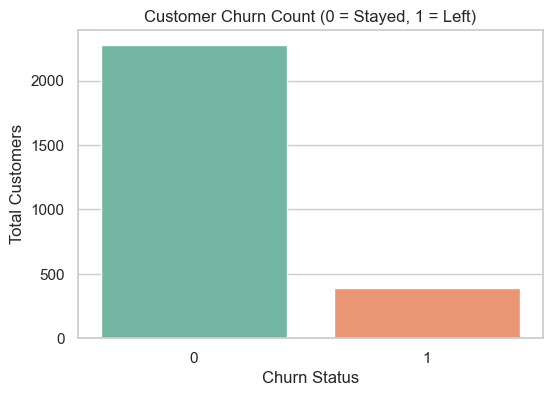

In [ ]:
#Count plot for Churn
#Calculate the exact percentages
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True)*100
print("Customer Churn Counts:")
print(churn_counts)
print("\nCustomer Churn Percntages:")
print(churn_percentages.round(2))

#Drawing a clean bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette = 'Set2')
plt.title('Customer Churn Count (0 = Stayed, 1 = Left)')
plt.xlabel('Churn Status')
plt.ylabel('Total Customers')
plt.show()


C:\Users\abdul\AppData\Local\Temp\ipykernel_23516\1552369295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Customer service calls', data=df, palette='pastel')


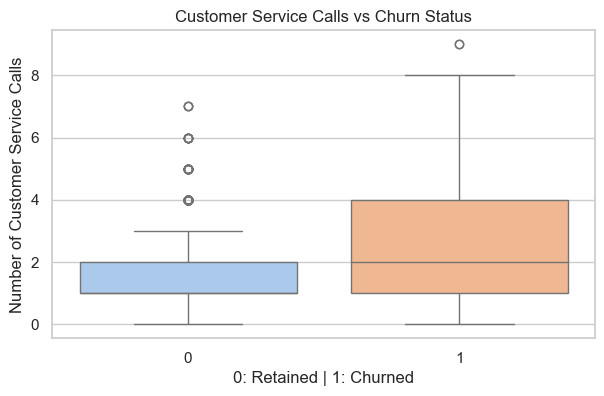

In [11]:
#Boxplot comparing service calls for Churned vs Non-Churned
plt.figure(figsize=(7, 4))
sns.boxplot(x='Churn', y='Customer service calls', data=df, palette='pastel')
plt.title('Customer Service Calls vs Churn Status')
plt.xlabel('0: Retained | 1: Churned')
plt.ylabel('Number of Customer Service Calls')
plt.show()

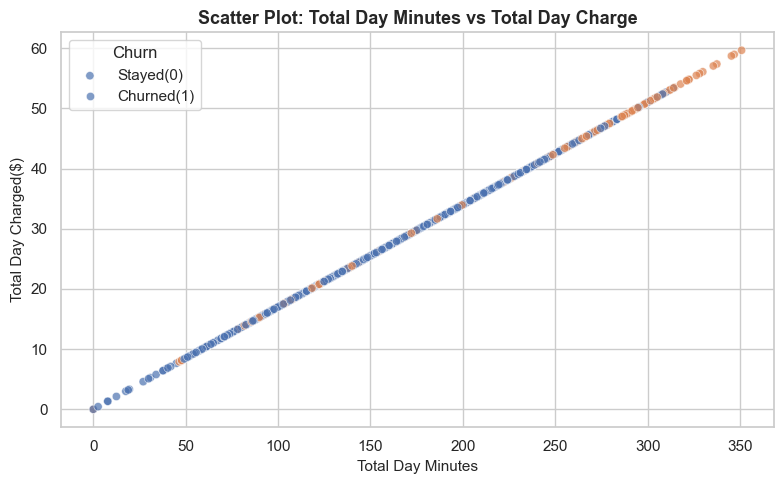

In [12]:
#Drawing a Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Total day minutes',
    y='Total day charge',
    hue='Churn',
    alpha=0.7
)
plt.title('Scatter Plot: Total Day Minutes vs Total Day Charge', fontsize=13, fontweight='bold')
plt.xlabel('Total Day Minutes', fontsize=11)
plt.ylabel('Total Day Charged($)', fontsize=11)
plt.legend(title='Churn', labels=['Stayed(0)', 'Churned(1)'])

plt.tight_layout()
plt.show()

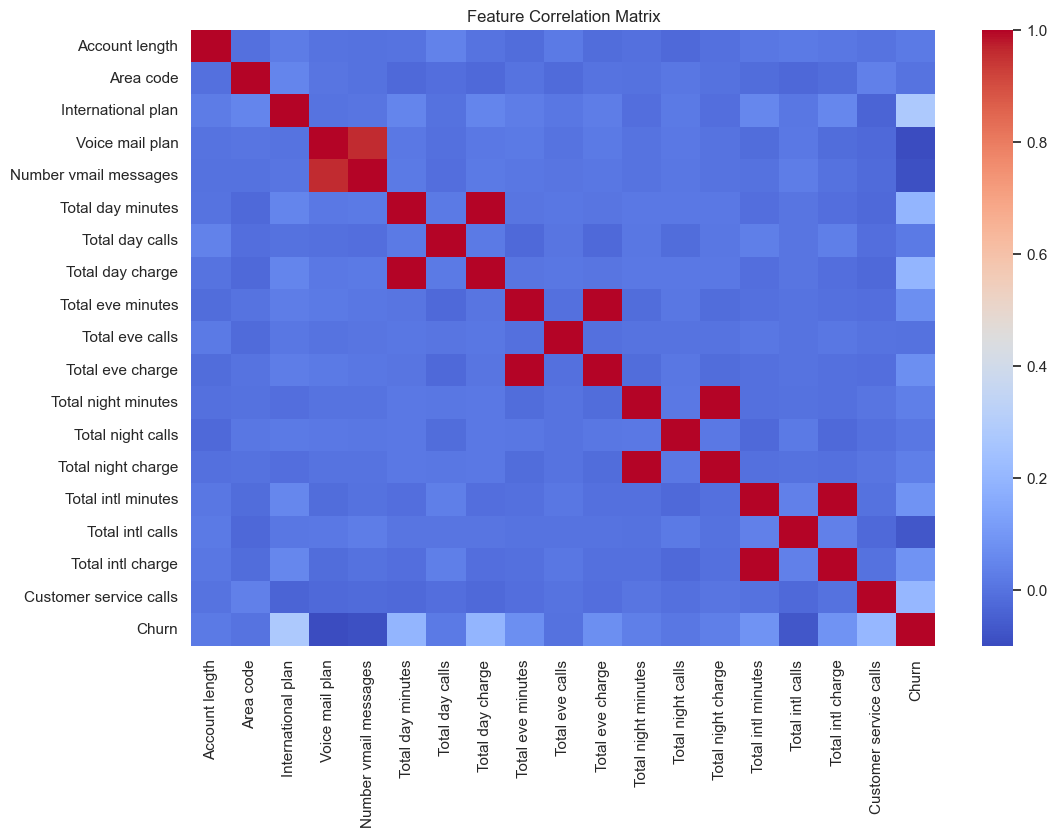

In [ ]:
#correlations which I'll be using a heatmap to visualize the relationshipas
plt.figure(figsize=(12, 8))

#Only compute correlations on numeric columns
numeric_columns = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_columns.corr()

#Drawing the heatmap
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.show()
# Meaning of the colors on the heatmap:
# Dark Red(Close to +1.0): Strong positive relationship
# Dark Blue(Close to -1.0): Strong negative relationship
# Light/Neutral: No relationship